In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
from matplotlib.colors import LinearSegmentedColormap
import cartopy.crs as ccrs
import cartopy.feature as cfeature

In [8]:
output_dir = 'rain_visualization'
os.makedirs(output_dir, exist_ok=True)

In [4]:
# 创建自定义蓝色调色板 - 从浅蓝到深蓝
blues = LinearSegmentedColormap.from_list('CustomBlues', 
                                         ['#FFFFFF00', '#EBF4FA40', '#D6E9F560', '#C1DFEF80', 
                                          '#ADD4EA90', '#98CAE4A0', '#83BFDFB0', '#6EB5D9C0', 
                                          '#59AAD4D0', '#45A0CEE0', '#3095C9E8', '#1B8BC3F0', 
                                          '#0680BEF5', '#0075B8F8', '#006AB2FA', '#005FACFF'])

C:\Users\96454\AppData\Local\Temp\ipykernel_92444\2146471491.py:97: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 0.95])


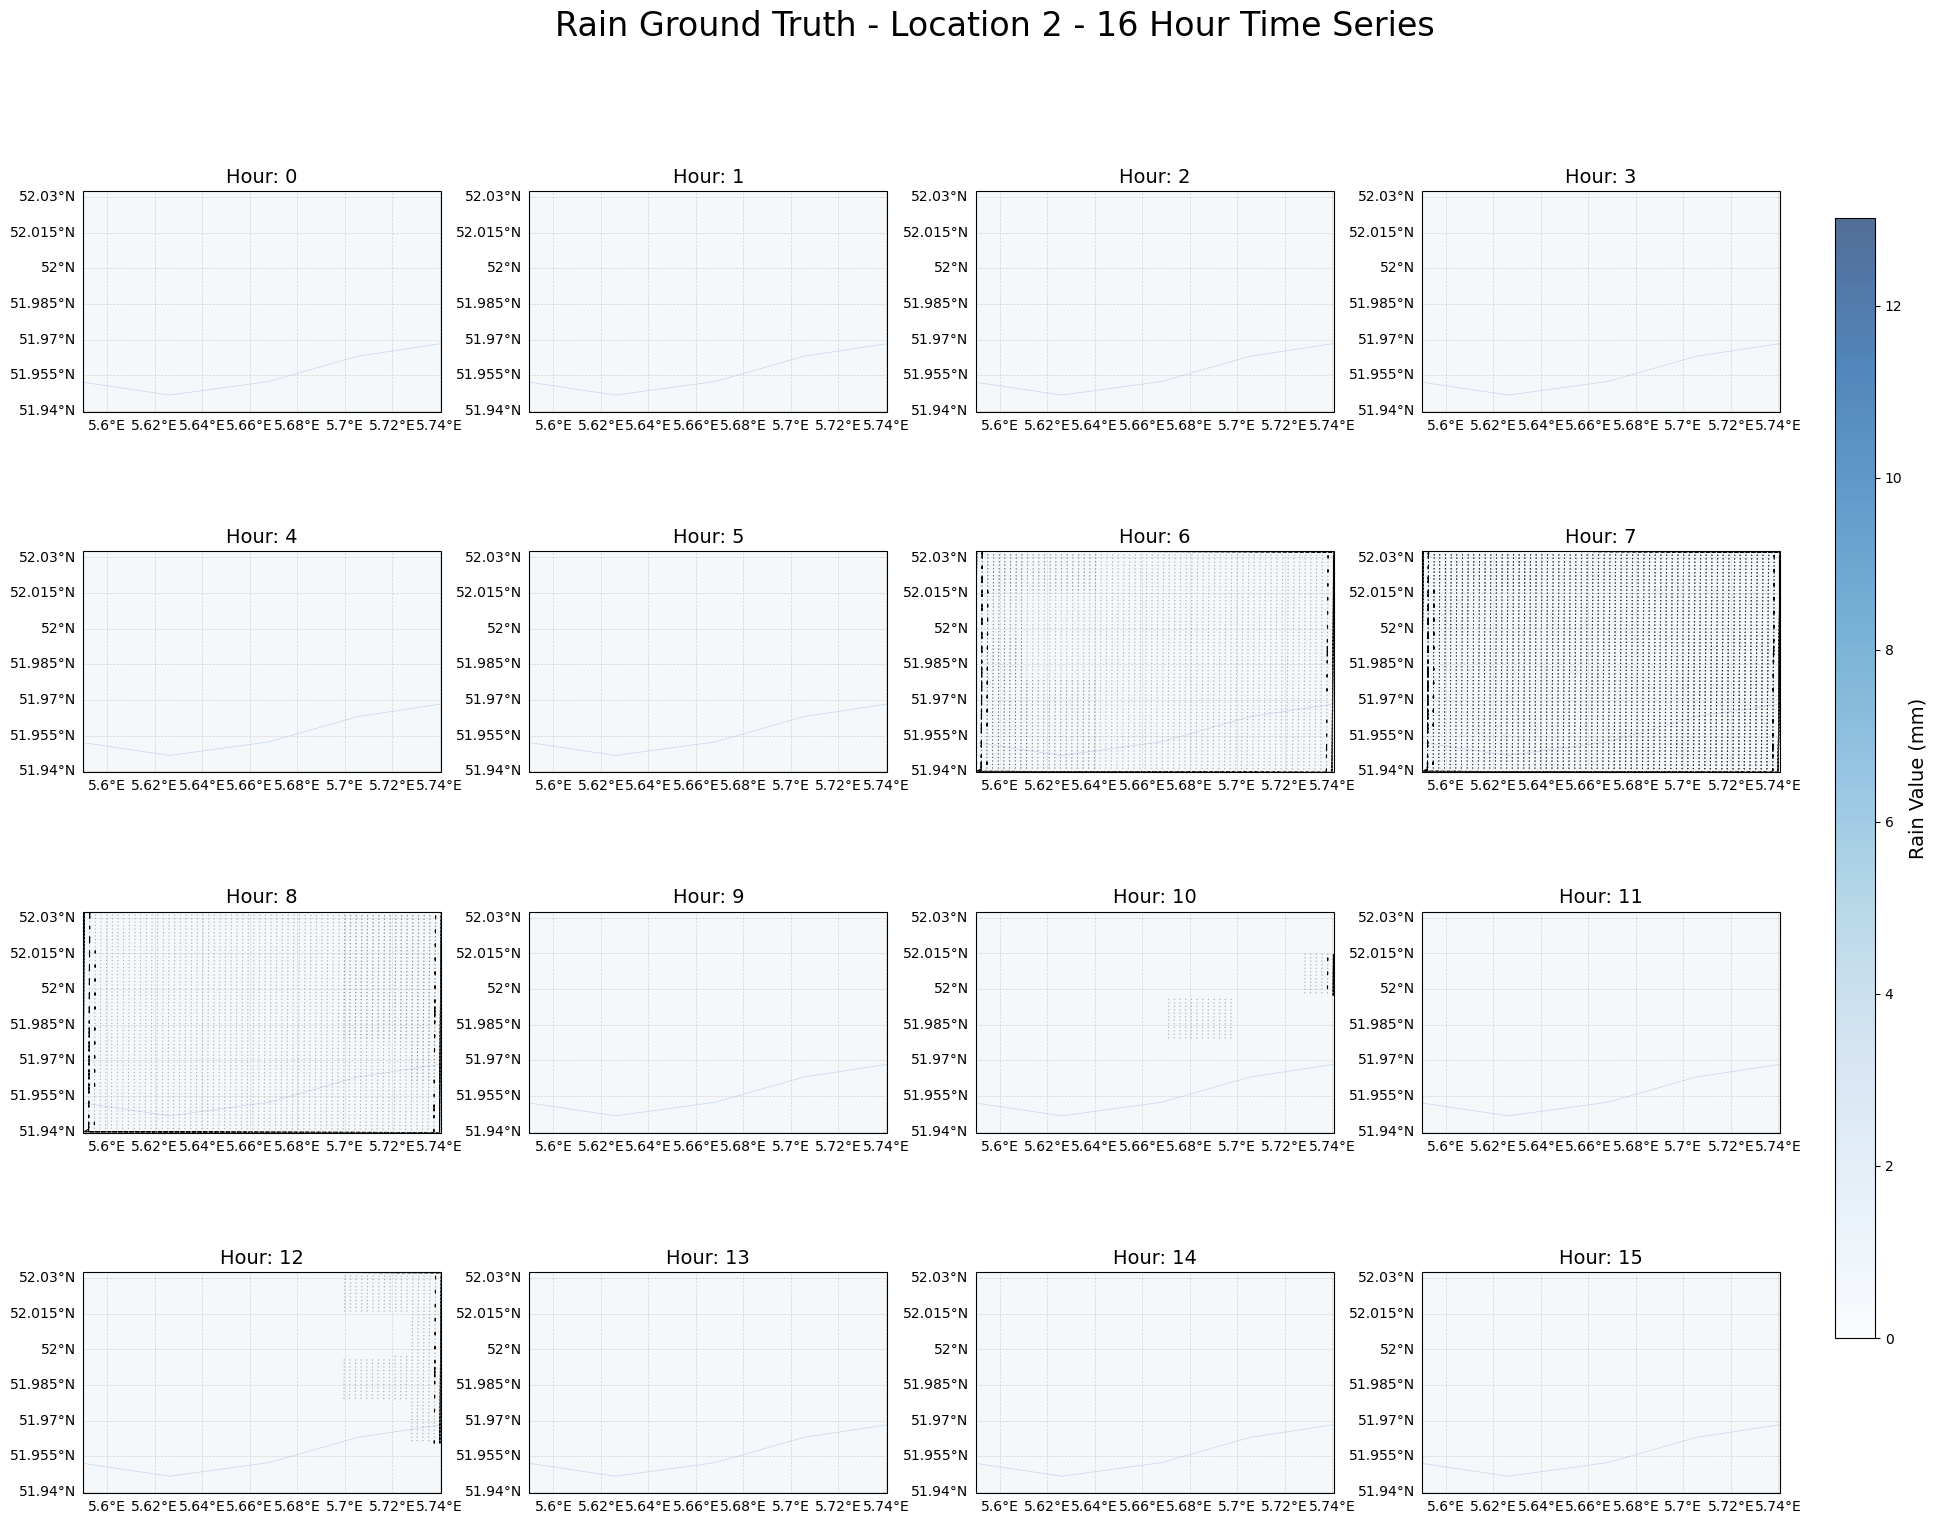

C:\Users\96454\AppData\Local\Temp\ipykernel_92444\2146471491.py:97: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 0.95])


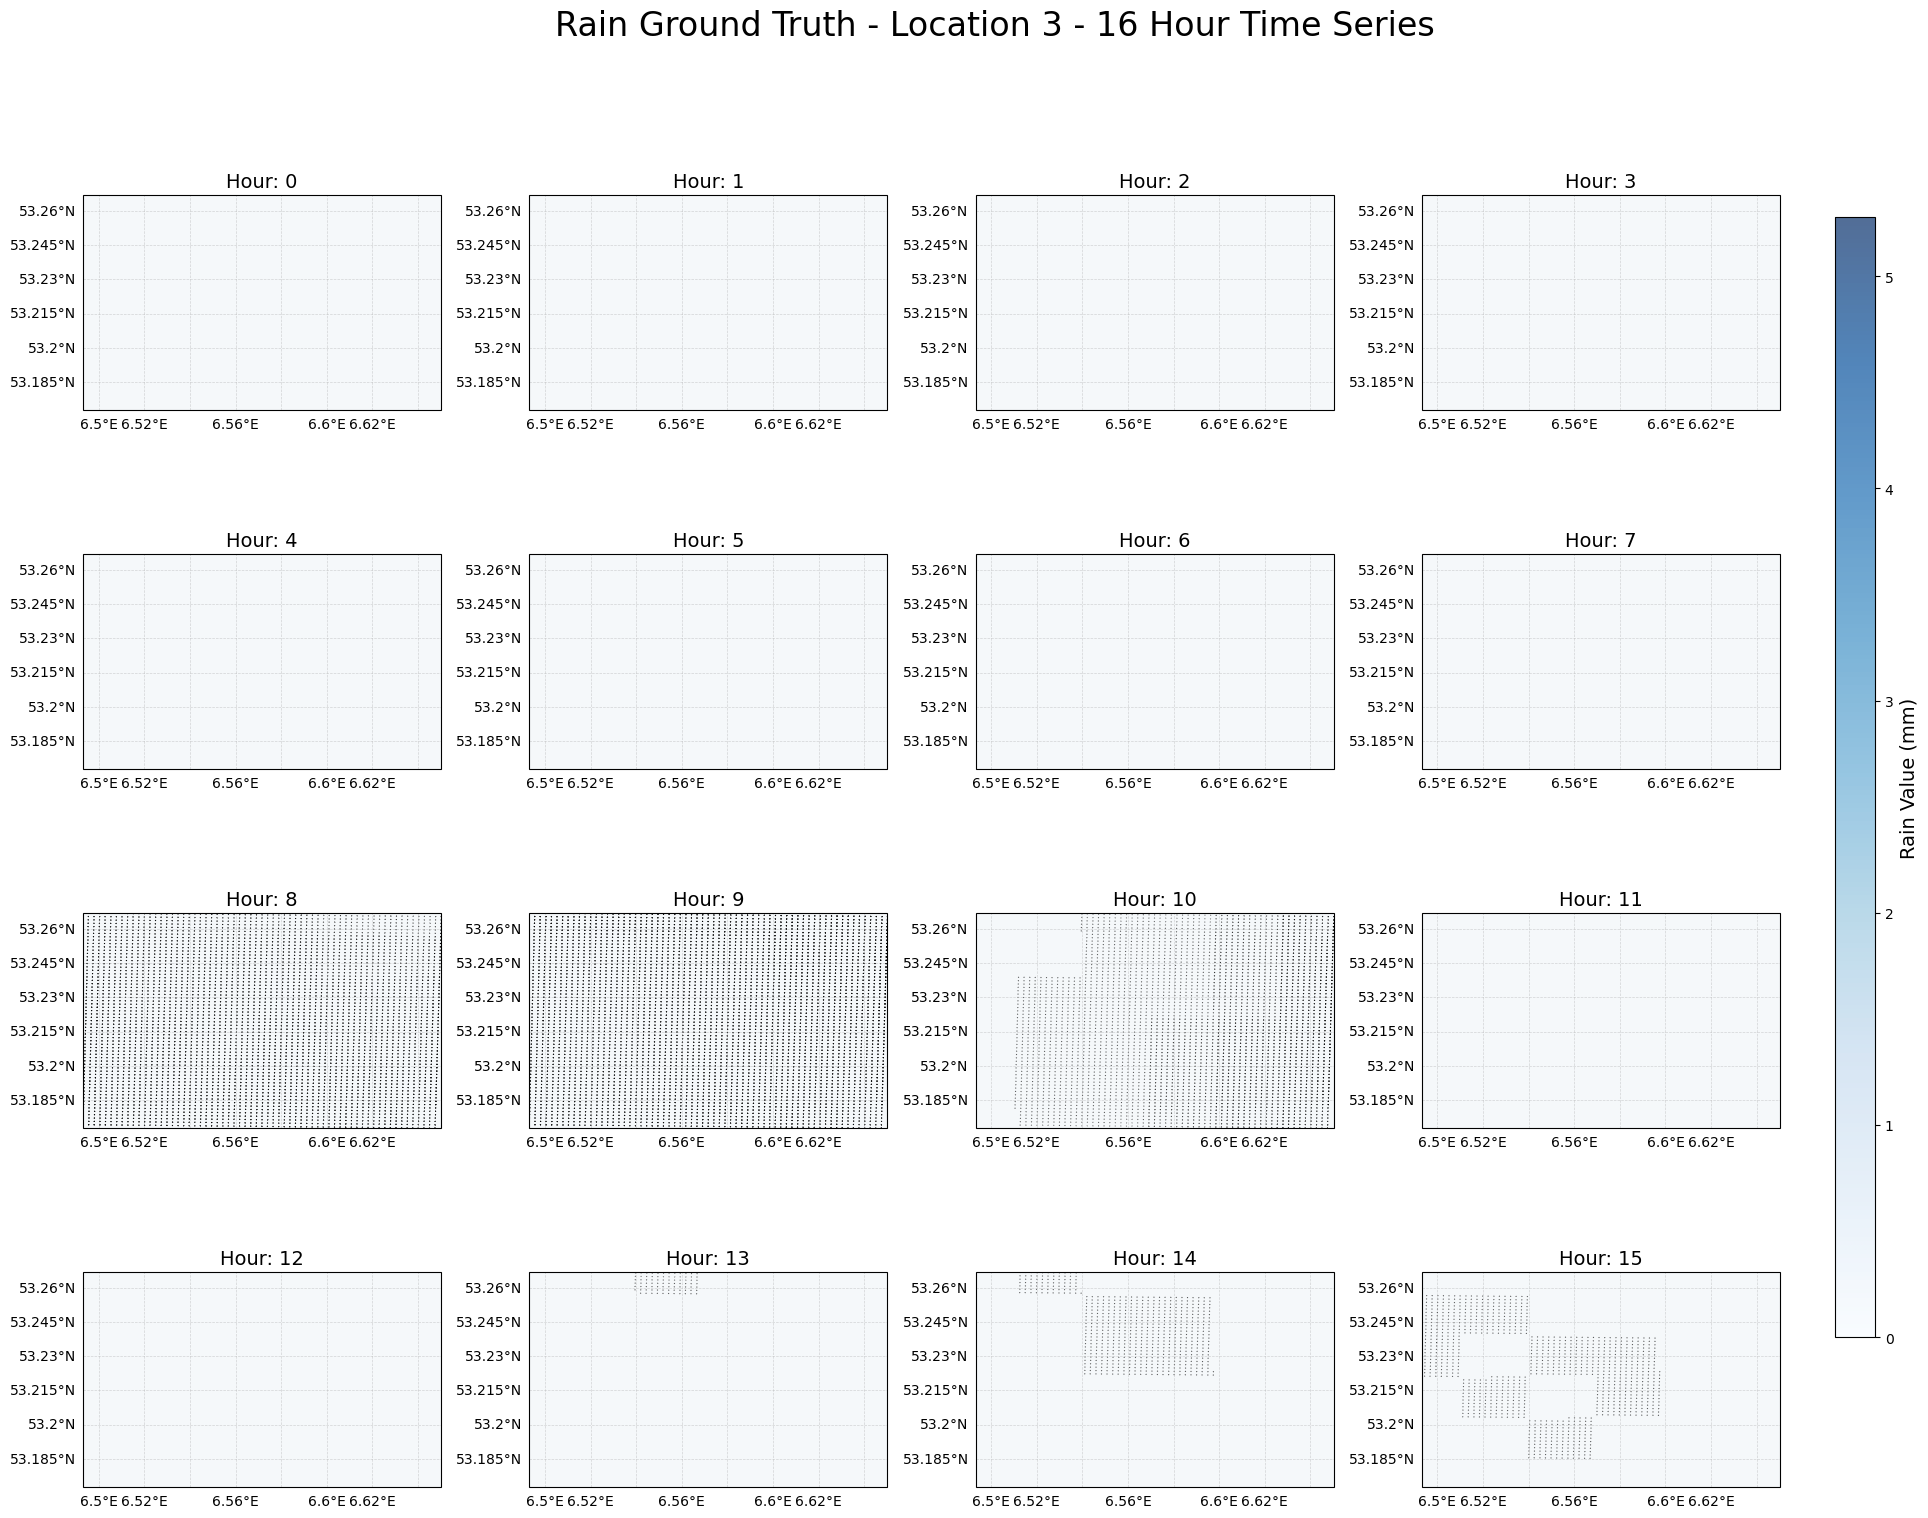

C:\Users\96454\AppData\Local\Temp\ipykernel_92444\2146471491.py:97: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 0.95])


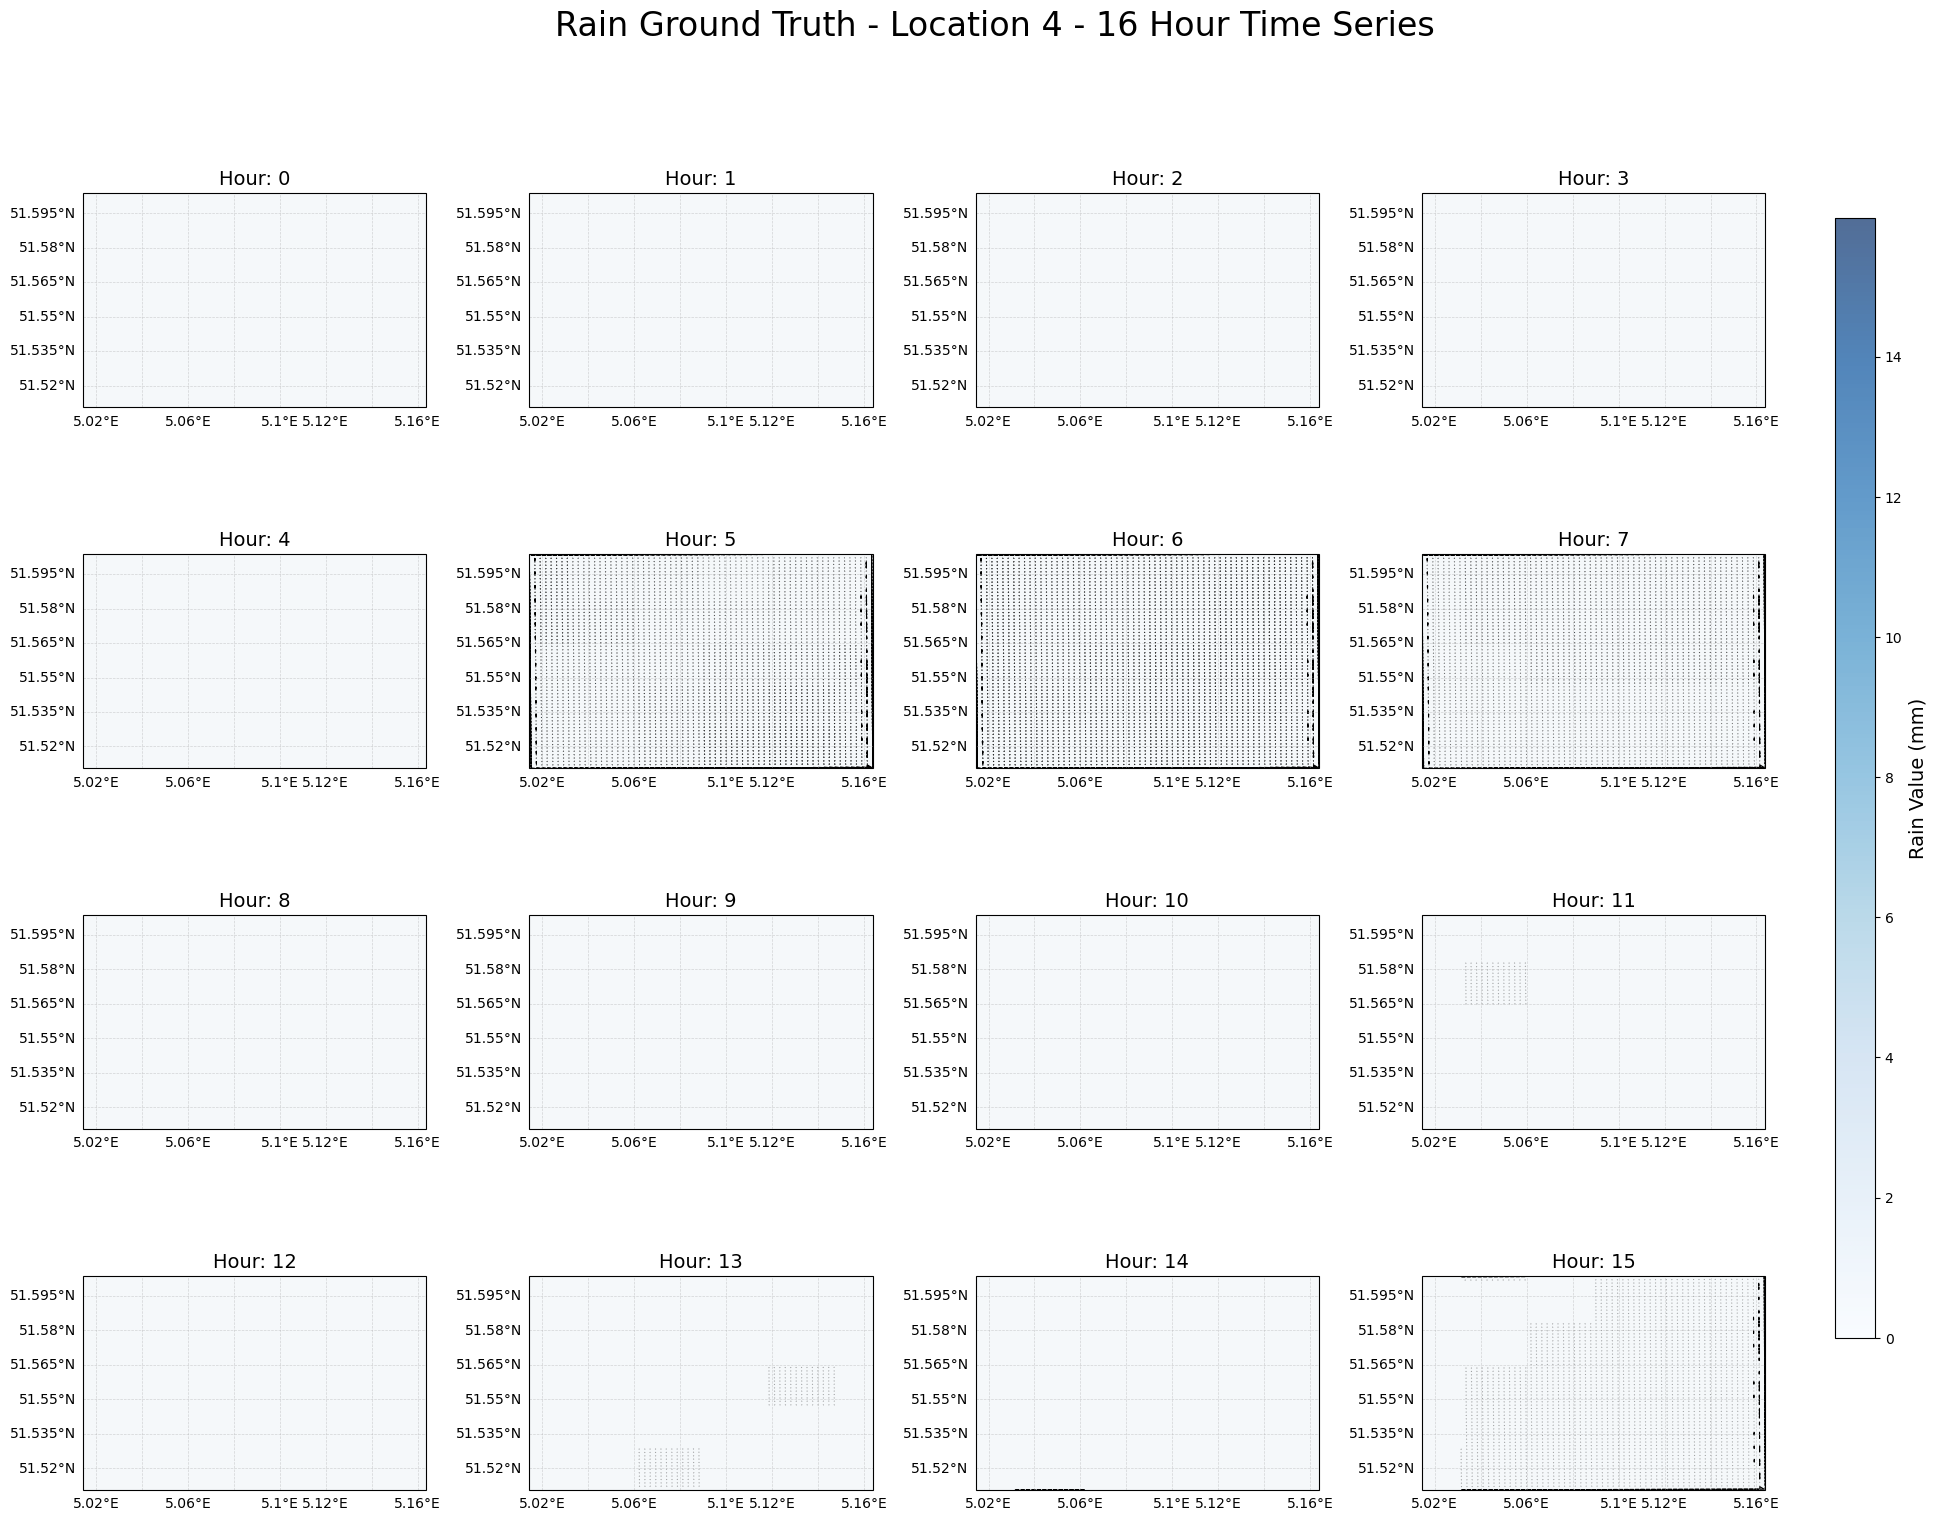

In [10]:
for location_num in [2, 3, 4]:
    # 读取对应的CSV文件
    file_path = f'interpolation_stat/results_location_{location_num}.csv'
    df = pd.read_csv(file_path)
    
    # 筛选出rain参数和ground_truth方法的数据
    rain_data = df[(df['parameter'] == 'rain') & (df['method'] == 'ground_truth')]
    
    if len(rain_data) == 0:
        print(f"No rain data found for location {location_num}")
        continue
    
    # 获取唯一的小时值，并确保它们是有序的
    hours = sorted(rain_data['hour'].unique())
    # 只取前16个小时
    hours = hours[:16]
    
    # 创建4x4网格图，显示16小时的降雨变化
    fig = plt.figure(figsize=(20, 16))
    fig.suptitle(f'Rain Ground Truth - Location {location_num} - 16 Hour Time Series', fontsize=24)
    
    # 获取经纬度范围，用于保持所有图的一致性
    min_lat, max_lat = rain_data['lat'].min(), rain_data['lat'].max()
    min_lon, max_lon = rain_data['lon'].min(), rain_data['lon'].max()
    
    # 获取降雨值范围，用于统一颜色比例
    min_rain, max_rain = rain_data['value'].min(), rain_data['value'].max()
    
    # 为每个小时创建一个子图
    for i, hour in enumerate(hours):
        if i >= 16:  # 只显示前16个小时
            break
            
        # 创建子图，使用Cartopy的投影
        ax = fig.add_subplot(4, 4, i+1, projection=ccrs.PlateCarree())
        
        # 获取特定小时的数据
        hour_data = rain_data[rain_data['hour'] == hour]
        
        if len(hour_data) == 0:
            ax.text(0.5, 0.5, f"No data for hour {hour}", 
                   horizontalalignment='center', verticalalignment='center',
                   transform=ax.transAxes)
            continue
        
        # 重塑数据为网格形式
        lats = sorted(hour_data['lat'].unique())
        lons = sorted(hour_data['lon'].unique())
        
        # 创建网格
        grid_data = np.zeros((len(lats), len(lons)))
        
        # 填充网格数据
        for _, row_data in hour_data.iterrows():
            lat_idx = lats.index(row_data['lat'])
            lon_idx = lons.index(row_data['lon'])
            grid_data[lat_idx, lon_idx] = row_data['value']
        
        # 创建网格坐标
        lon_grid, lat_grid = np.meshgrid(lons, lats)
        
        # 添加地图特征
        ax.add_feature(cfeature.COASTLINE.with_scale('10m'), linewidth=0.8)
        ax.add_feature(cfeature.BORDERS.with_scale('10m'), linestyle=':', linewidth=0.6)
        ax.add_feature(cfeature.RIVERS.with_scale('10m'), linewidth=0.5, alpha=0.5)
        ax.add_feature(cfeature.LAND.with_scale('10m'), facecolor='lightgray', alpha=0.3)
        ax.add_feature(cfeature.OCEAN.with_scale('10m'), facecolor='lightblue', alpha=0.3)
        
        # 使用pcolormesh而不是contourf，可能会显示得更好
        im = ax.pcolormesh(lon_grid, lat_grid, grid_data, 
                         cmap='Blues', vmin=min_rain, vmax=max_rain,
                         transform=ccrs.PlateCarree(), alpha=0.7)
        
        # 添加轮廓线
        contour = ax.contour(lon_grid, lat_grid, grid_data, 
                           levels=np.linspace(min_rain, max_rain, 8),
                           colors='black', linewidths=0.8,
                           transform=ccrs.PlateCarree())
        
        # 设置标题
        ax.set_title(f'Hour: {hour}', fontsize=14)
        
        # 设置地图范围
        ax.set_extent([min_lon, max_lon, min_lat, max_lat], crs=ccrs.PlateCarree())
        
        # 添加网格线和坐标标签
        gl = ax.gridlines(draw_labels=True, linewidth=0.5, alpha=0.5, linestyle='--')
        gl.top_labels = False
        gl.right_labels = False
    
    # 添加颜色条
    cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
    cbar = fig.colorbar(im, cax=cbar_ax)
    cbar.set_label('Rain Value (mm)', fontsize=14)
    
    # 调整布局
    plt.tight_layout(rect=[0, 0, 0.9, 0.95])
    
    # 显示图像
    plt.show()

## 平均降雨量时间序列

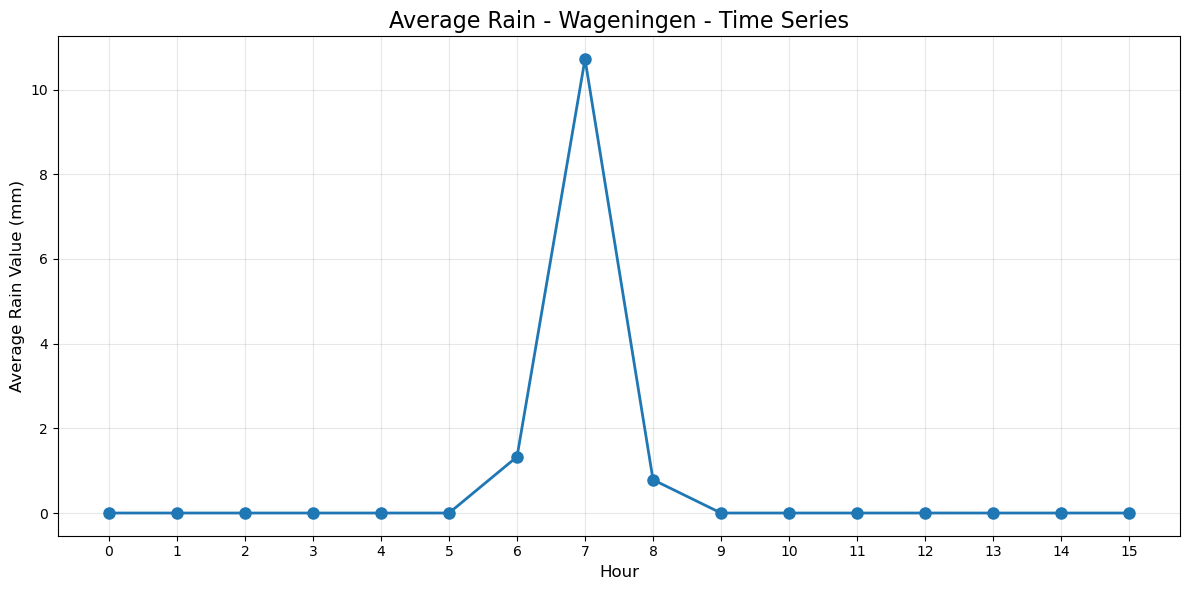

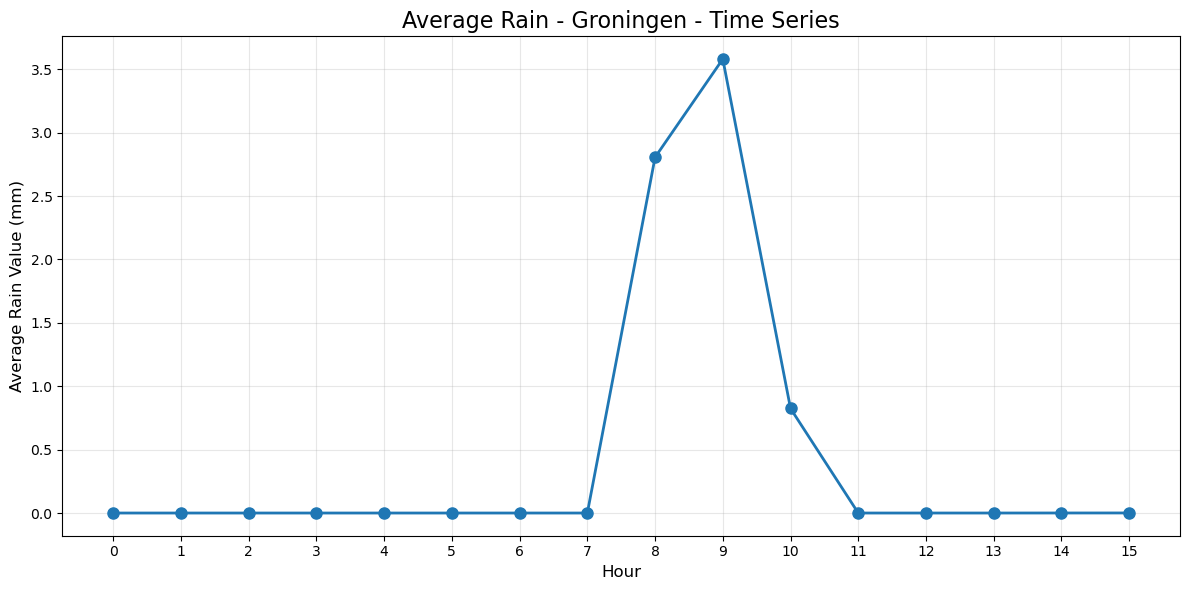

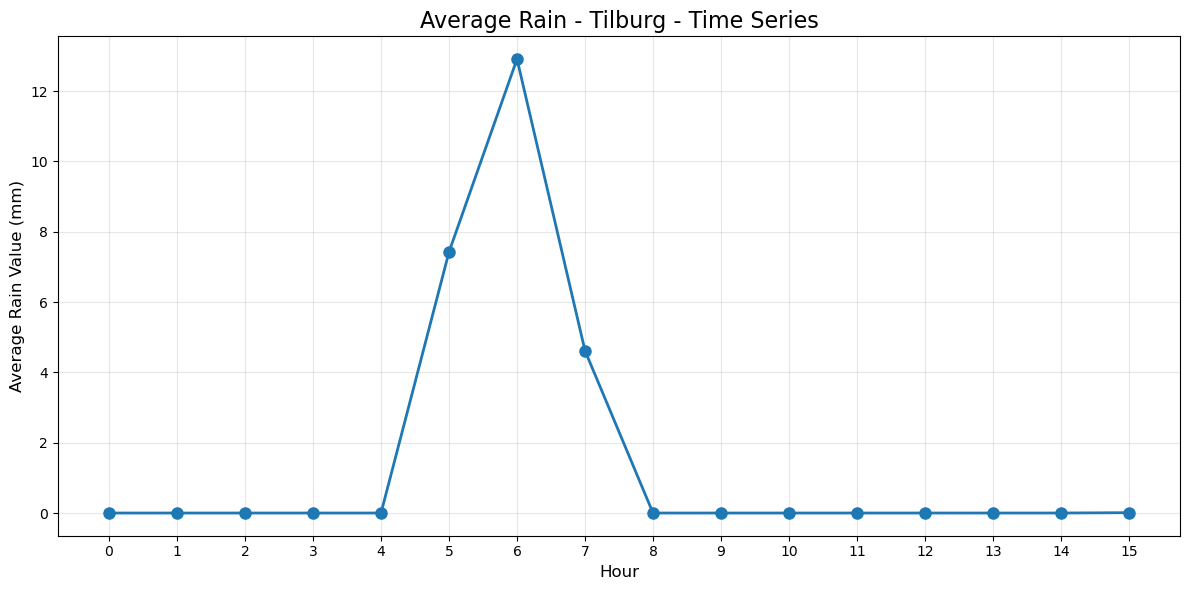

In [4]:
# 处理每个location的数据
# 处理每个location的数据
location_city_map = {
    2: "Wageningen",
    3: "Groningen",
    4: "Tilburg"
}

for location_num in [2, 3, 4]:
    # 读取对应的CSV文件
    file_path = f'interpolation_stat/results_location_{location_num}.csv'
    df = pd.read_csv(file_path)
    
    # 获取对应的城市名称
    city_name = location_city_map[location_num]
    
    # 筛选出rain参数和ground_truth方法的数据
    rain_data = df[(df['parameter'] == 'rain') & (df['method'] == 'ground_truth')]
    
    if len(rain_data) == 0:
        print(f"No rain data found for {city_name}")
        continue
    
    # 获取唯一的小时值，并确保它们是有序的
    hours = sorted(rain_data['hour'].unique())
    
    # 计算每个小时的平均降雨量
    hourly_avg = []
    for hour in hours:
        hour_data = rain_data[rain_data['hour'] == hour]
        avg_rain = hour_data['value'].mean()
        hourly_avg.append(avg_rain)
    
    # 创建时间序列图
    plt.figure(figsize=(12, 6))
    plt.plot(hours, hourly_avg, 'o-', linewidth=2, markersize=8, color='#1f77b4')
    
    # 添加标题和标签
    plt.title(f'Average Rain - {city_name} - Time Series', fontsize=16)
    plt.xlabel('Hour', fontsize=12)
    plt.ylabel('Average Rain Value (mm)', fontsize=12)
    plt.grid(True, alpha=0.3)
    
    # 设置x轴刻度
    plt.xticks(hours)
    
    # 美化图表
    plt.tight_layout()
    
    # 显示图像
    plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.io.img_tiles import OSM

# 读取location 2的数据
file_path = 'interpolation_stat/results_location_2.csv'
df = pd.read_csv(file_path)

# 筛选出rain参数和ground_truth方法的数据
rain_data = df[(df['parameter'] == 'rain') & (df['method'] == 'ground_truth')]

# 筛选出5-9小时的数据
selected_hours = list(range(5, 10))  # 5, 6, 7, 8, 9
selected_data = rain_data[rain_data['hour'].isin(selected_hours)]

# 获取经纬度范围
min_lat, max_lat = selected_data['lat'].min(), selected_data['lat'].max()
min_lon, max_lon = selected_data['lon'].min(), selected_data['lon'].max()

# 获取降雨值范围
min_rain, max_rain = selected_data['value'].min(), selected_data['value'].max()

# 创建OpenStreetMap瓦片源
osm_tiles = OSM()

# 创建子图，每个小时一个
fig = plt.figure(figsize=(20, 10))
fig.suptitle('Rain in Wageningen (Location 2) - Hours 5-9', fontsize=20)

for i, hour in enumerate(selected_hours):
    # 获取特定小时的数据
    hour_data = selected_data[selected_data['hour'] == hour]
    
    # 创建子图
    ax = fig.add_subplot(1, 5, i+1, projection=ccrs.PlateCarree())
    
    # 重塑数据为网格形式
    lats = sorted(hour_data['lat'].unique())
    lons = sorted(hour_data['lon'].unique())
    
    # 创建网格
    grid_data = np.zeros((len(lats), len(lons)))
    
    # 填充网格数据
    for _, row_data in hour_data.iterrows():
        lat_idx = lats.index(row_data['lat'])
        lon_idx = lons.index(row_data['lon'])
        grid_data[lat_idx, lon_idx] = row_data['value']
    
    # 创建网格坐标
    lon_grid, lat_grid = np.meshgrid(lons, lats)
    
    try:
        # 添加OpenStreetMap底图
        ax.add_image(osm_tiles, 12)  # 12是缩放级别，可以根据需要调整
    except Exception as e:
        print(f"Error adding OSM tiles: {e}")
        # 添加基本地图特征作为备选
        ax.add_feature(cfeature.COASTLINE.with_scale('10m'))
        ax.add_feature(cfeature.BORDERS.with_scale('10m'))
        ax.add_feature(cfeature.RIVERS.with_scale('10m'))
        ax.add_feature(cfeature.LAND.with_scale('10m'), facecolor='lightgray')
        ax.add_feature(cfeature.OCEAN.with_scale('10m'), facecolor='lightblue')
    
    # 绘制降雨数据
    im = ax.pcolormesh(lon_grid, lat_grid, grid_data, 
                     cmap='Blues', vmin=min_rain, vmax=max_rain,
                     transform=ccrs.PlateCarree(), alpha=0.7)
    
    # 添加轮廓线
    contour = ax.contour(lon_grid, lat_grid, grid_data, 
                       levels=np.linspace(min_rain, max_rain, 6),
                       colors='black', linewidths=0.5,
                       transform=ccrs.PlateCarree())
    
    # 设置标题
    ax.set_title(f'Hour: {hour}', fontsize=14)
    
    # 设置地图范围
    ax.set_extent([min_lon, max_lon, min_lat, max_lat], crs=ccrs.PlateCarree())
    
    # 添加网格线和坐标标签
    gl = ax.gridlines(draw_labels=True, linewidth=0.5, alpha=0.5, linestyle='--')
    gl.top_labels = False
    gl.right_labels = False

# 添加颜色条
cbar_ax = fig.add_axes([0.92, 0.2, 0.02, 0.6])
cbar = fig.colorbar(im, cax=cbar_ax)
cbar.set_label('Rain Value (mm)', fontsize=14)

# 调整布局
plt.tight_layout(rect=[0, 0, 0.9, 0.95])

# 显示图像
plt.show()

MemoryError: Unable to allocate 73.1 MiB for an array with shape (9582883,) and data type float64

Error in callback <function _draw_all_if_interactive at 0x0000018F5F101C60> (for post_execute), with arguments args (),kwargs {}:


KeyboardInterrupt: 

C:\Users\96454\AppData\Local\Temp\ipykernel_55504\3441109932.py:26: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  blues = plt.cm.get_cmap('Blues')
C:\Users\96454\AppData\Local\Temp\ipykernel_55504\3441109932.py:84: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 0.95])


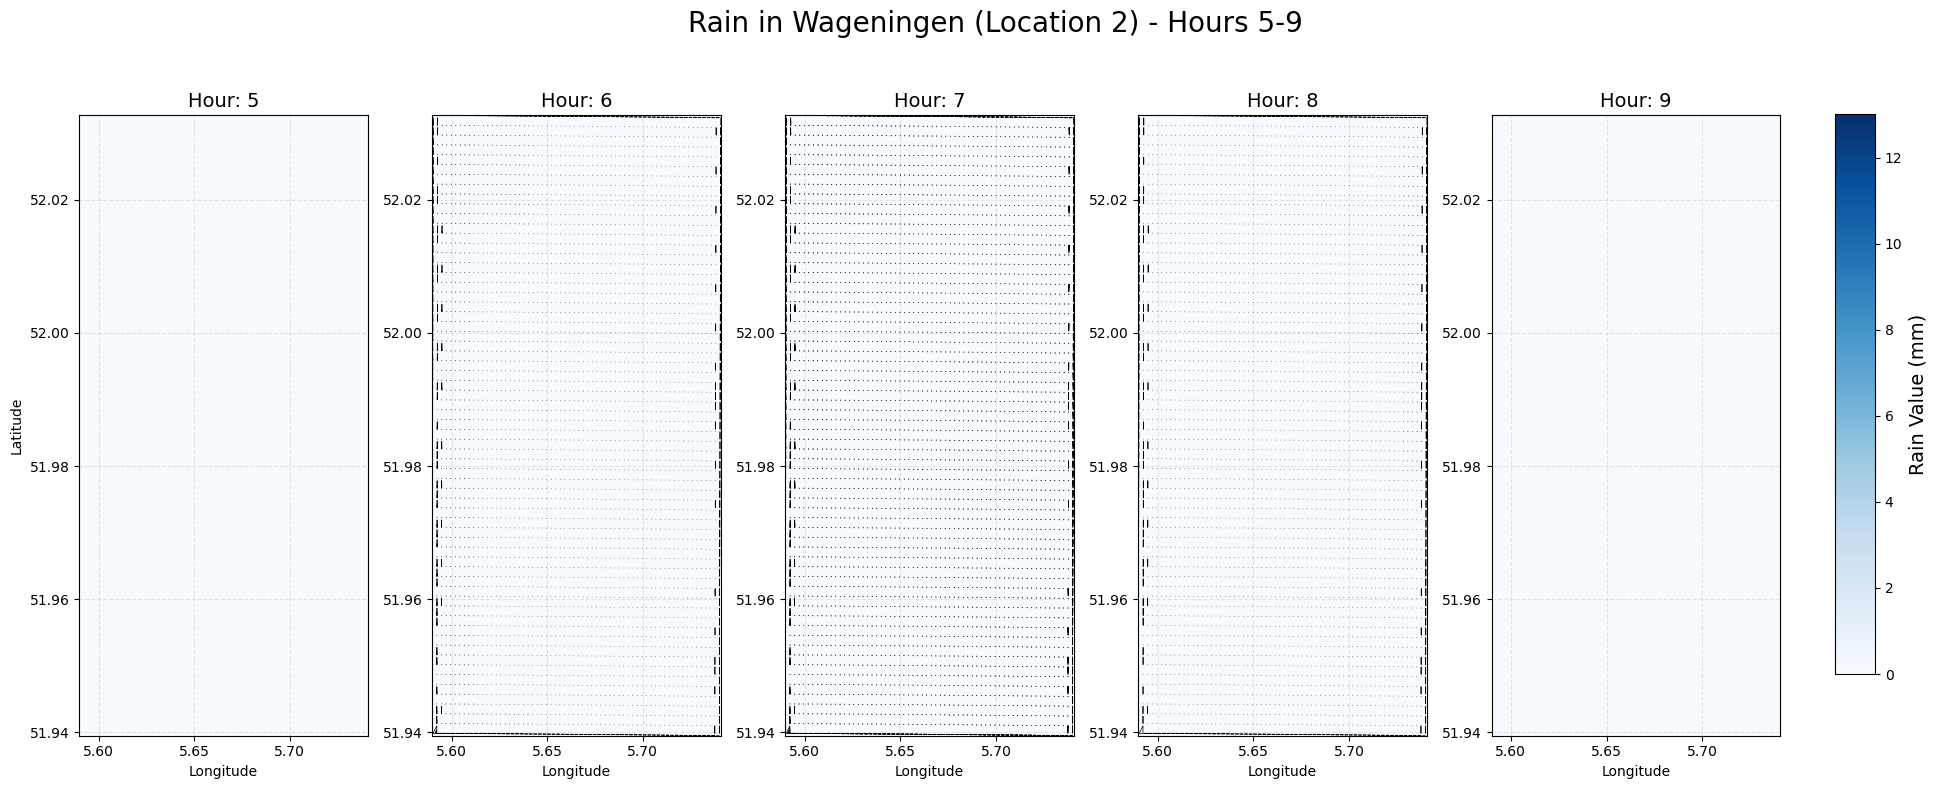

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
from matplotlib.colors import LinearSegmentedColormap

# 读取location 2的数据
file_path = 'interpolation_stat/results_location_2.csv'
df = pd.read_csv(file_path)

# 筛选出rain参数和ground_truth方法的数据
rain_data = df[(df['parameter'] == 'rain') & (df['method'] == 'ground_truth')]

# 筛选出5-9小时的数据
selected_hours = list(range(5, 10))  # 5, 6, 7, 8, 9
selected_data = rain_data[rain_data['hour'].isin(selected_hours)]

# 获取经纬度范围
min_lat, max_lat = selected_data['lat'].min(), selected_data['lat'].max()
min_lon, max_lon = selected_data['lon'].min(), selected_data['lon'].max()

# 获取降雨值范围
min_rain, max_rain = selected_data['value'].min(), selected_data['value'].max()

# 创建自定义蓝色调色板
blues = plt.cm.get_cmap('Blues')

# 创建子图，每个小时一个
fig, axes = plt.subplots(1, 5, figsize=(20, 8))
fig.suptitle('Rain in Wageningen (Location 2) - Hours 5-9', fontsize=20)

for i, hour in enumerate(selected_hours):
    # 获取特定小时的数据
    hour_data = selected_data[selected_data['hour'] == hour]
    
    # 获取子图
    ax = axes[i]
    
    # 重塑数据为网格形式
    lats = sorted(hour_data['lat'].unique())
    lons = sorted(hour_data['lon'].unique())
    
    # 创建网格
    grid_data = np.zeros((len(lats), len(lons)))
    
    # 填充网格数据
    for _, row_data in hour_data.iterrows():
        lat_idx = lats.index(row_data['lat'])
        lon_idx = lons.index(row_data['lon'])
        grid_data[lat_idx, lon_idx] = row_data['value']
    
    # 创建网格坐标
    lon_grid, lat_grid = np.meshgrid(lons, lats)
    
    # 绘制降雨数据
    im = ax.pcolormesh(lon_grid, lat_grid, grid_data, 
                     cmap=blues, vmin=min_rain, vmax=max_rain)
    
    # 添加轮廓线
    contour = ax.contour(lon_grid, lat_grid, grid_data, 
                       levels=np.linspace(min_rain, max_rain, 6),
                       colors='black', linewidths=0.5)
    
    # 添加轮廓线标签
    ax.clabel(contour, inline=True, fontsize=8, fmt='%.1f')
    
    # 设置标题
    ax.set_title(f'Hour: {hour}', fontsize=14)
    
    # 设置轴标签
    ax.set_xlabel('Longitude', fontsize=10)
    if i == 0:
        ax.set_ylabel('Latitude', fontsize=10)
    
    # 添加网格线
    ax.grid(True, linestyle='--', alpha=0.3)

# 添加颜色条
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
cbar = fig.colorbar(im, cax=cbar_ax)
cbar.set_label('Rain Value (mm)', fontsize=14)

# 调整布局
plt.tight_layout(rect=[0, 0, 0.9, 0.95])

# 显示图像
plt.show()

C:\Users\96454\AppData\Local\Temp\ipykernel_55504\4104066083.py:92: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 0.95])


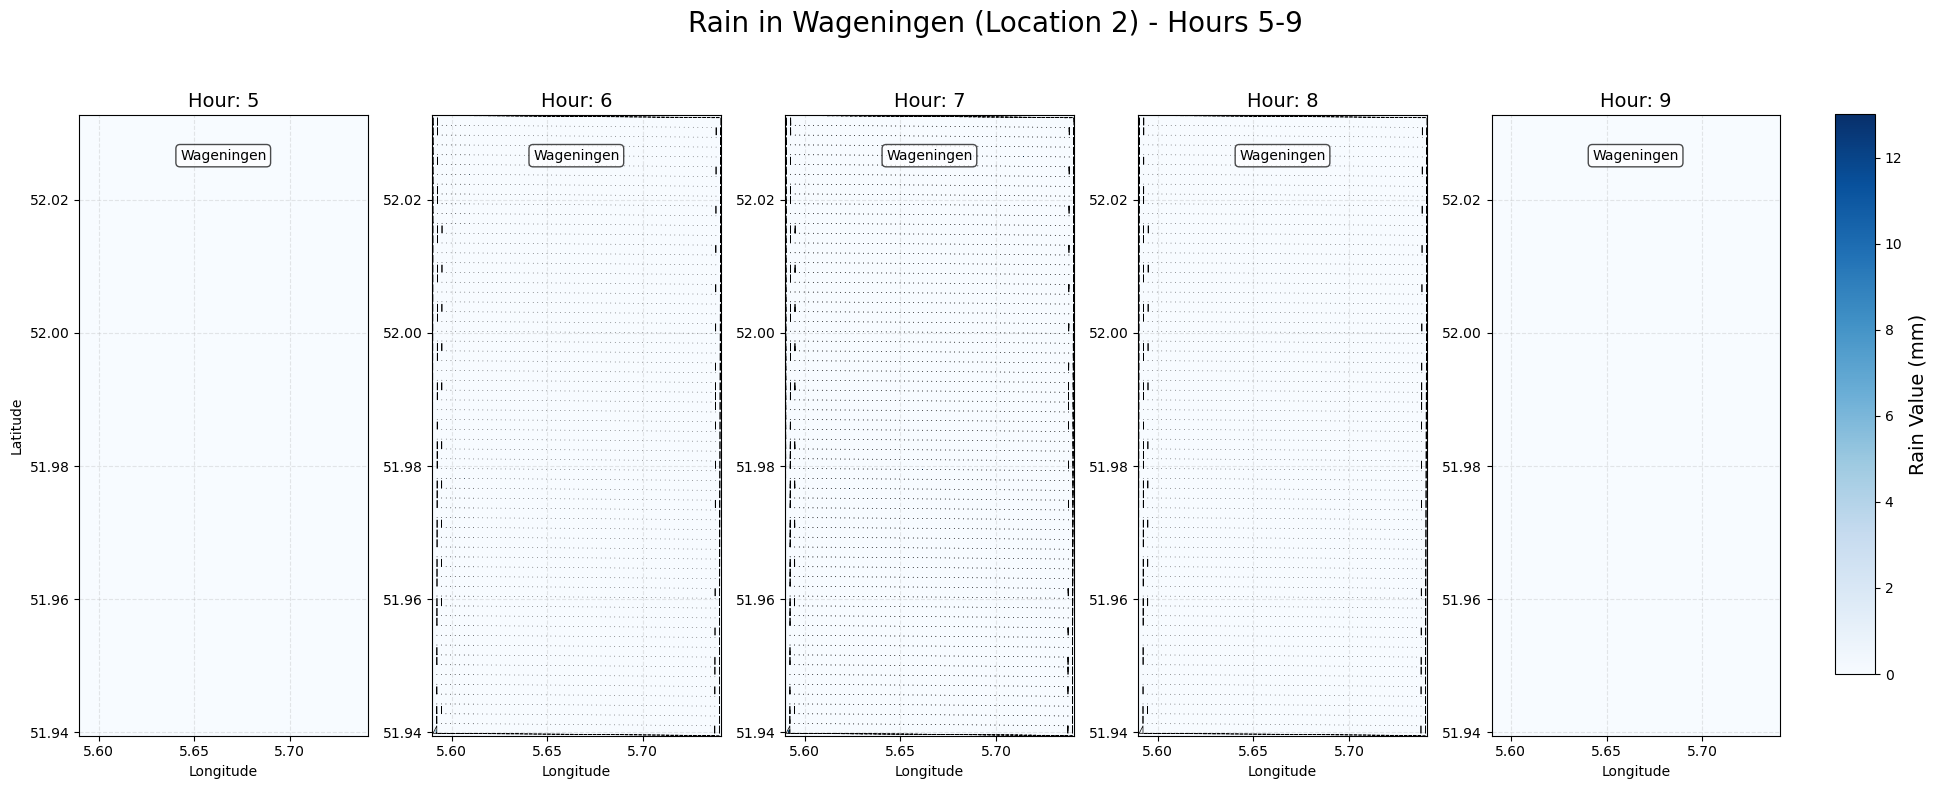

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
from matplotlib.colors import LinearSegmentedColormap

# 读取location 2的数据
file_path = 'interpolation_stat/results_location_2.csv'
df = pd.read_csv(file_path)

# 筛选出rain参数和ground_truth方法的数据
rain_data = df[(df['parameter'] == 'rain') & (df['method'] == 'ground_truth')]

# 筛选出5-9小时的数据
selected_hours = list(range(5, 10))  # 5, 6, 7, 8, 9
selected_data = rain_data[rain_data['hour'].isin(selected_hours)]

# 获取经纬度范围
min_lat, max_lat = selected_data['lat'].min(), selected_data['lat'].max()
min_lon, max_lon = selected_data['lon'].min(), selected_data['lon'].max()

# 获取降雨值范围
min_rain, max_rain = selected_data['value'].min(), selected_data['value'].max()

# 创建子图，每个小时一个
fig, axes = plt.subplots(1, 5, figsize=(20, 8))
fig.suptitle('Rain in Wageningen (Location 2) - Hours 5-9', fontsize=20)

# 对每个小时的数据进行处理
for i, hour in enumerate(selected_hours):
    # 获取特定小时的数据
    hour_data = selected_data[selected_data['hour'] == hour]
    
    # 获取子图
    ax = axes[i]
    
    # 重塑数据为网格形式 - 使用更高效的方法
    lats = sorted(hour_data['lat'].unique())
    lons = sorted(hour_data['lon'].unique())
    
    # 创建网格 - 使用更高效的方法
    grid_size = (len(lats), len(lons))
    grid_data = np.zeros(grid_size)
    
    # 创建经纬度索引映射，避免重复查找索引
    lat_indices = {lat: i for i, lat in enumerate(lats)}
    lon_indices = {lon: i for i, lon in enumerate(lons)}
    
    # 填充网格数据 - 使用更高效的方法
    for _, row in hour_data.iterrows():
        lat_idx = lat_indices[row['lat']]
        lon_idx = lon_indices[row['lon']]
        grid_data[lat_idx, lon_idx] = row['value']
    
    # 创建网格坐标
    lon_grid, lat_grid = np.meshgrid(lons, lats)
    
    # 绘制降雨数据 - 使用pcolormesh，它比contourf更高效
    im = ax.pcolormesh(lon_grid, lat_grid, grid_data, 
                     cmap='Blues', vmin=min_rain, vmax=max_rain)
    
    # 添加轮廓线 - 减少轮廓线的数量以提高效率
    contour = ax.contour(lon_grid, lat_grid, grid_data, 
                       levels=np.linspace(min_rain, max_rain, 4),
                       colors='black', linewidths=0.5)
    
    # 添加轮廓线标签
    ax.clabel(contour, inline=True, fontsize=8, fmt='%.1f')
    
    # 设置标题
    ax.set_title(f'Hour: {hour}', fontsize=14)
    
    # 设置轴标签
    ax.set_xlabel('Longitude', fontsize=10)
    if i == 0:
        ax.set_ylabel('Latitude', fontsize=10)
    
    # 添加网格线
    ax.grid(True, linestyle='--', alpha=0.3)
    
    # 添加一些地理参考点 - 简单的文本标记
    ax.text(np.mean(lons), max_lat - 0.005, 'Wageningen', 
           ha='center', va='top', fontsize=10, 
           bbox=dict(facecolor='white', alpha=0.7, boxstyle='round'))

# 添加颜色条
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
cbar = fig.colorbar(im, cax=cbar_ax)
cbar.set_label('Rain Value (mm)', fontsize=14)

# 调整布局
plt.tight_layout(rect=[0, 0, 0.9, 0.95])

# 显示图像
plt.show()

数据点数量: 20480
降雨值范围: 0.0 到 13.0185546875
降雨值平均: 2.566898012161255
降雨值中位数: 0.09375


C:\Users\96454\AppData\Local\Temp\ipykernel_55504\1573946964.py:67: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 0.95])


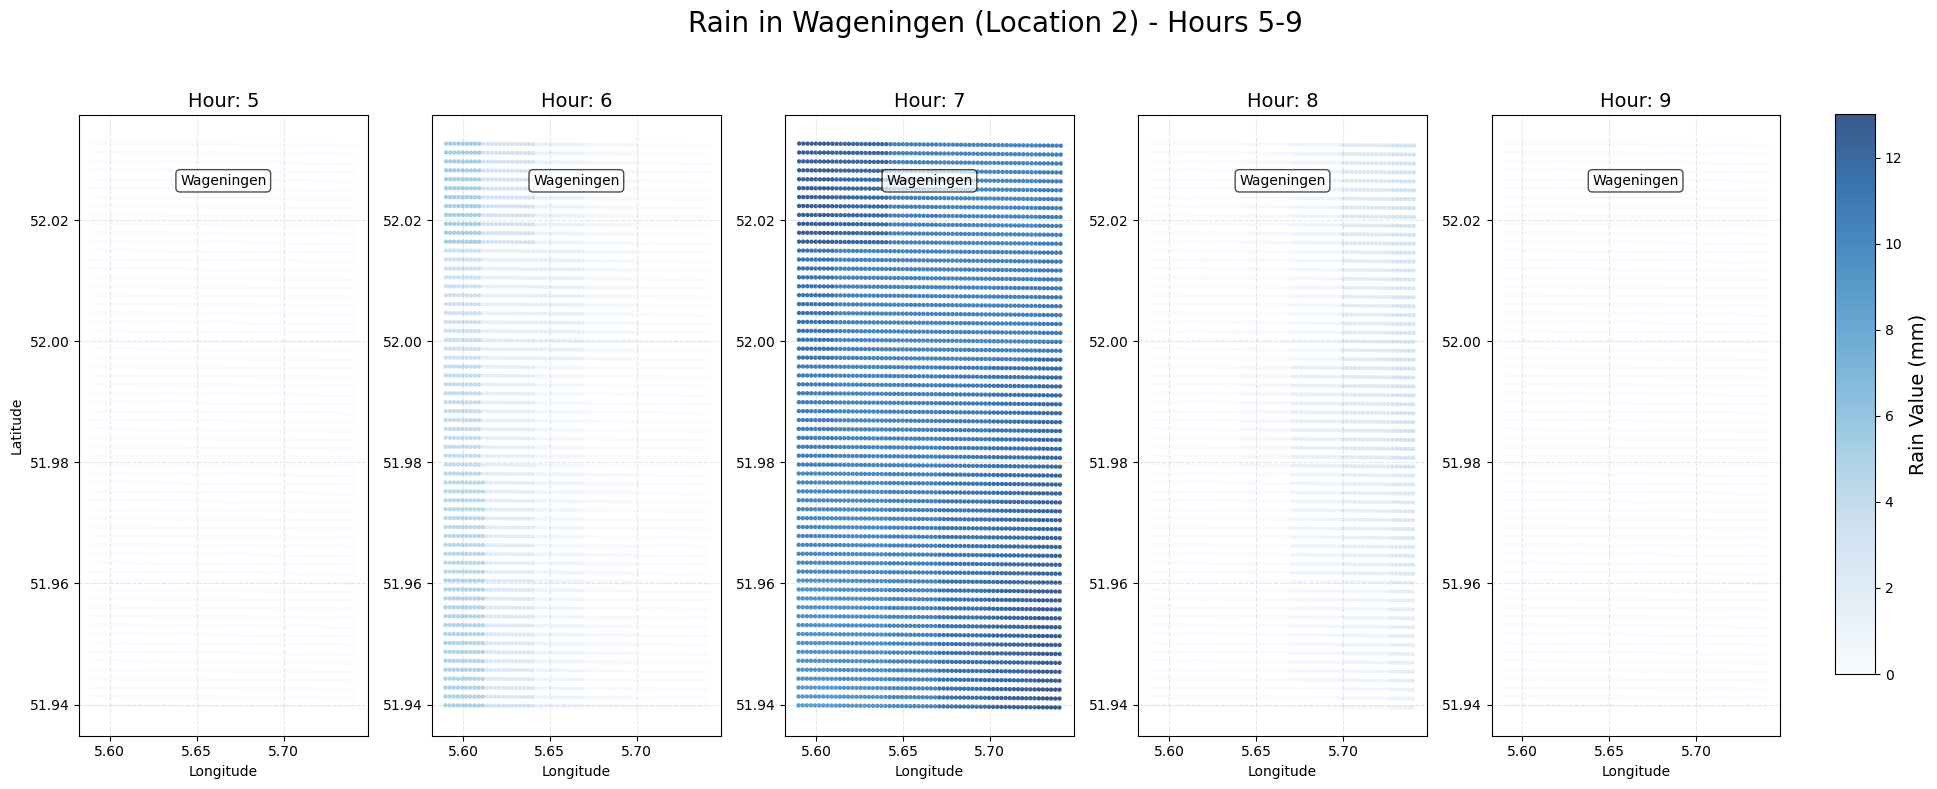

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

# 读取location 2的数据
file_path = 'interpolation_stat/results_location_2.csv'
df = pd.read_csv(file_path)

# 筛选出rain参数和ground_truth方法的数据
rain_data = df[(df['parameter'] == 'rain') & (df['method'] == 'ground_truth')]

# 筛选出5-9小时的数据
selected_hours = list(range(5, 10))  # 5, 6, 7, 8, 9
selected_data = rain_data[rain_data['hour'].isin(selected_hours)]

# 获取降雨值范围
min_rain = selected_data['value'].min()
max_rain = selected_data['value'].max()

# 打印一些数据统计信息，帮助我们理解数据
print(f"数据点数量: {len(selected_data)}")
print(f"降雨值范围: {min_rain} 到 {max_rain}")
print(f"降雨值平均: {selected_data['value'].mean()}")
print(f"降雨值中位数: {selected_data['value'].median()}")

# 创建子图，每个小时一个
fig, axes = plt.subplots(1, 5, figsize=(20, 8))
fig.suptitle('Rain in Wageningen (Location 2) - Hours 5-9', fontsize=20)

# 对每个小时的数据进行处理
for i, hour in enumerate(selected_hours):
    # 获取特定小时的数据
    hour_data = selected_data[selected_data['hour'] == hour]
    
    # 获取子图
    ax = axes[i]
    
    # 使用散点图直接显示数据点
    scatter = ax.scatter(hour_data['lon'], hour_data['lat'], 
                        c=hour_data['value'], cmap='Blues', 
                        s=10, alpha=0.8, edgecolors='none',
                        vmin=min_rain, vmax=max_rain)
    
    # 设置标题
    ax.set_title(f'Hour: {hour}', fontsize=14)
    
    # 设置轴标签
    ax.set_xlabel('Longitude', fontsize=10)
    if i == 0:
        ax.set_ylabel('Latitude', fontsize=10)
    
    # 添加网格线
    ax.grid(True, linestyle='--', alpha=0.3)
    
    # 添加地理参考点
    ax.text(np.mean(hour_data['lon']), hour_data['lat'].max() - 0.005, 'Wageningen', 
           ha='center', va='top', fontsize=10, 
           bbox=dict(facecolor='white', alpha=0.7, boxstyle='round'))

# 添加颜色条
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
cbar = fig.colorbar(scatter, cax=cbar_ax)
cbar.set_label('Rain Value (mm)', fontsize=14)

# 调整布局
plt.tight_layout(rect=[0, 0, 0.9, 0.95])

# 显示图像
plt.show()